# Regresión lineal simple

Importación de librerías.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Lectura del archivo CSV por medio de Pandas. 

In [2]:
data = pd.read_csv('/home/yimy/Documentos/Libros/aprender_ml/Regresion/articulos_ml.csv')
data.shape

(161, 8)

In [3]:
data.head()

,Title,url,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
0,What is Machine Learning and how do we use it ...,https://blog.signals.network/what-is-machine-l...,1888,1,2.0,2,34,200000
1,10 Companies Using Machine Learning in Cool Ways,NaN,1742,9,NaN,9,5,25000
2,How Artificial Intelligence Is Revolutionizing...,NaN,962,6,0.0,1,10,42000
3,Dbrain and the Blockchain of Artificial Intell...,NaN,1221,3,NaN,2,68,200000
4,Nasa finds entire solar system filled with eig...,NaN,2039,1,104.0,4,131,200000


In [4]:
data.describe()

,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
count,161.000000,161.000000,129.000000,161.000000,161.000000,161.000000
mean,1808.260870,9.739130,8.782946,3.670807,98.124224,27948.347826
std,1141.919385,47.271625,13.142822,3.418290,114.337535,43408.006839
min,250.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,990.000000,3.000000,2.000000,1.000000,31.000000,2800.000000
50%,1674.000000,5.000000,6.000000,3.000000,62.000000,16458.000000
75%,2369.000000,7.000000,12.000000,5.000000,124.000000,35691.000000
max,8401.000000,600.000000,104.000000,22.000000,1002.000000,350000.000000


Visualización de características de entrada

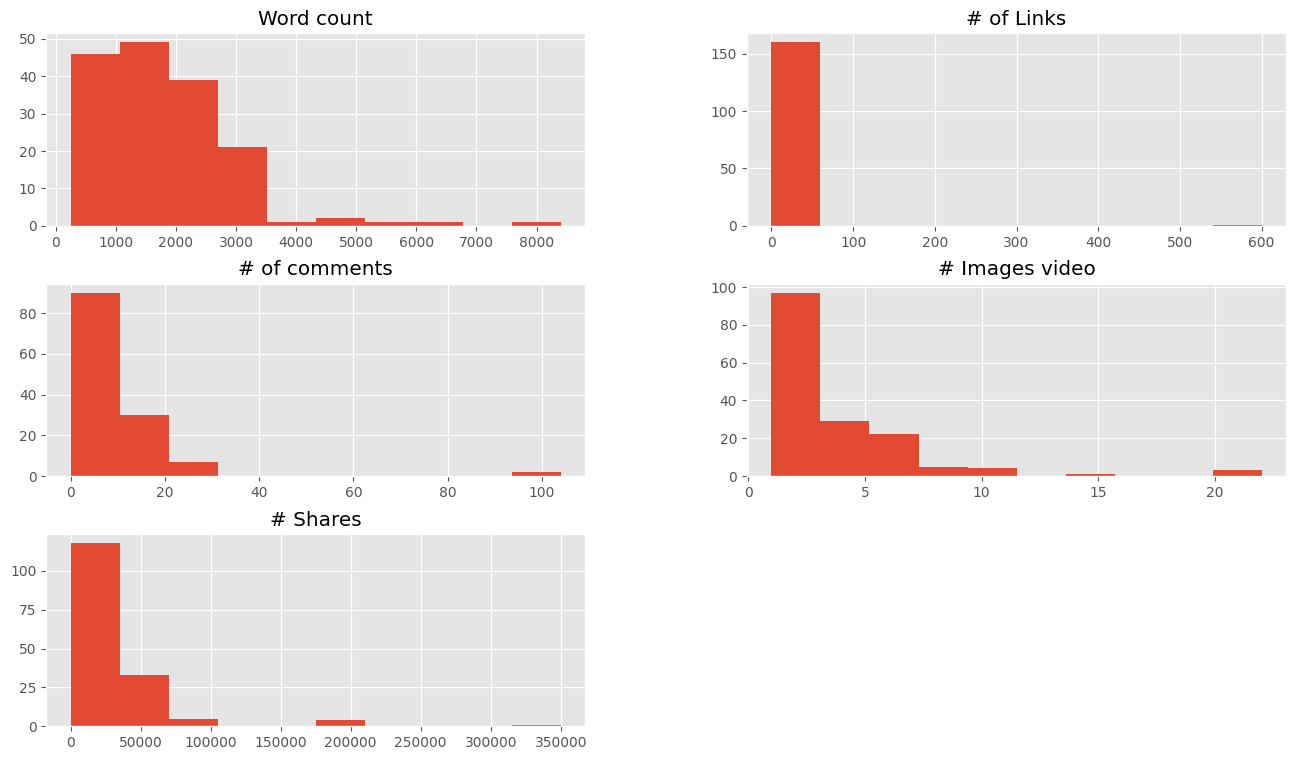

In [5]:
data.drop(['Title', 'url', 'Elapsed days'], axis=1).hist()
plt.show()

Filtración de datos.

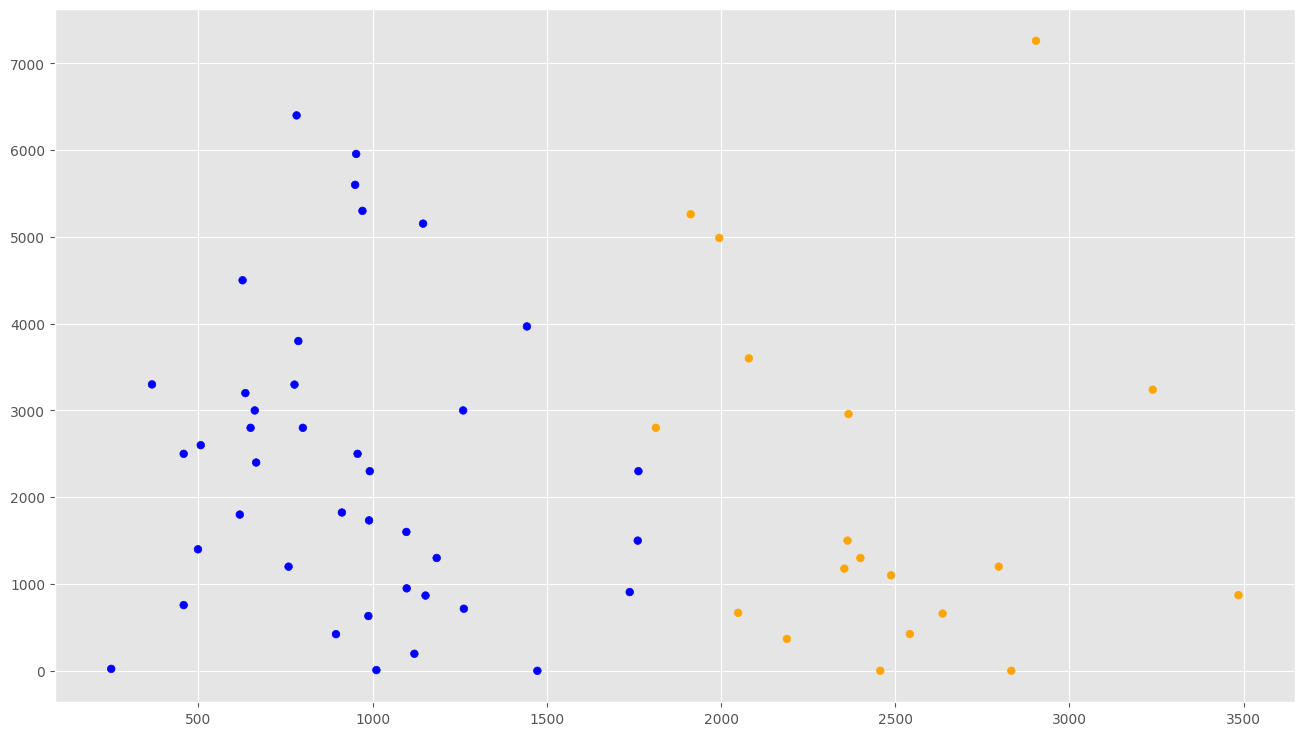

In [6]:
filtered_data = data[(data['Word count'] <= 3500) & (data['# Shares'] <=8000)]

colores = ['orange', 'blue']
tamanios = [30, 60]

f1 = filtered_data['Word count'].values
f2 = filtered_data['# Shares'].values

asignar = []
for index, row in filtered_data.iterrows():
    if (row['Word count']>1808):
        asignar.append(colores[0])
    else:
        asignar.append(colores[1])
plt.scatter(f1, f2, c=asignar, s=tamanios[0])
plt.show()

## Regresión lineal con Python y SKLearn

Creación del modelo lineal y se imprimen los coeficientes y puntajes obtenidos.

In [7]:
# Datos de entrenamiento X_train y y_train

dataX = filtered_data[["Word count"]]
X_train = np.array(dataX)
y_train = filtered_data['# Shares'].values

# Objeto de regresión lineal
regr = linear_model.LinearRegression()

# Entrenamiento del modelo
regr.fit(X_train, y_train)

# Predicciones en regresión lineal
y_pred = regr.predict(X_train)

# Coeficientes obtenidos
print('Coefficients: \n', regr.coef_)
# Este es el valor donde corta el eje Y (en X=0)
print('Independent term: \n', regr.intercept_)
# Error cuadrático medio
print('Mean squared error: %.2f' % mean_squared_error(y_train, y_pred))
# Puntaje de varianza. El mejor puntaje es 1.0
print('Variance score: %.2f' % r2_score(y_train, y_pred))

Coefficients: 
 [-0.29404078]
Independent term: 
 2689.3647241014255
Mean squared error: 3150416.34
Variance score: 0.02


### Visualización de la recta

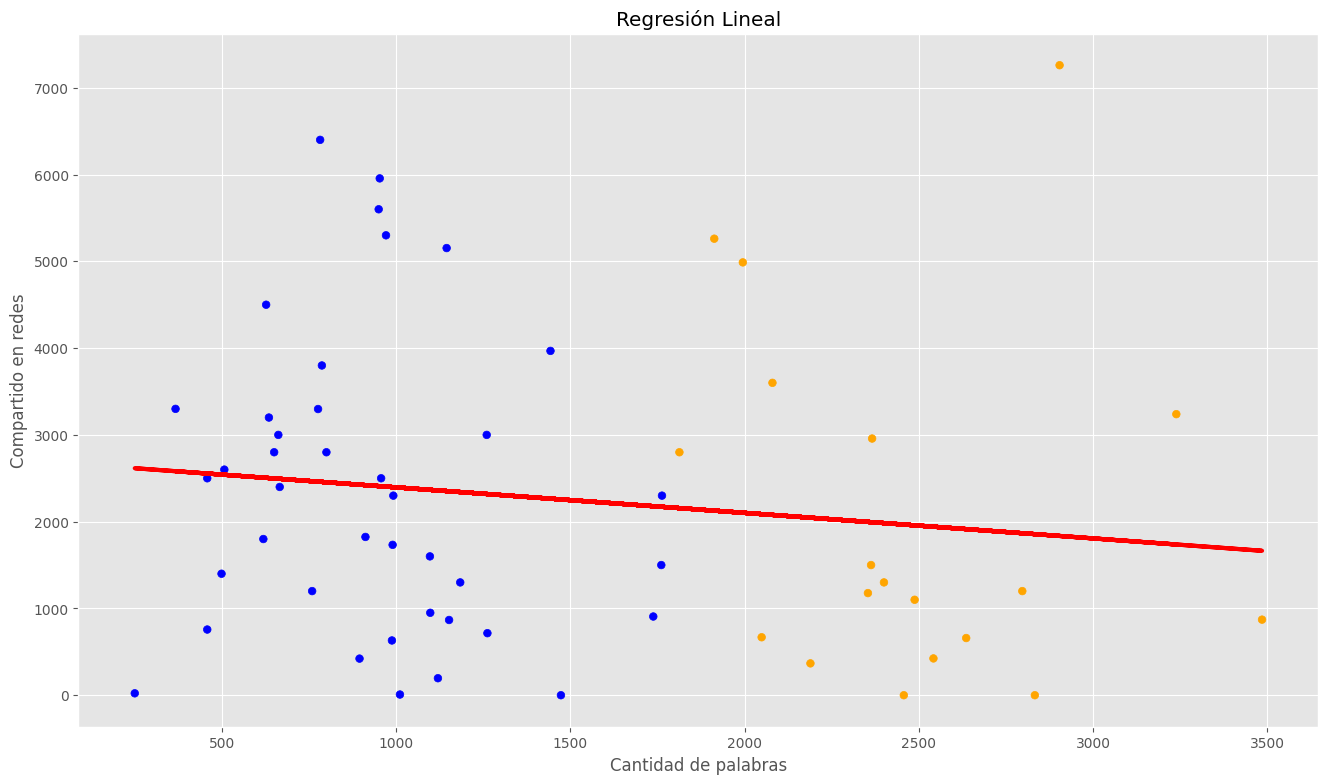

In [8]:
plt.scatter(X_train[:,0], y_train, c=asignar, s=tamanios[0])
plt.plot(X_train[:,0], y_pred, color='red', linewidth=3)
plt.xlabel('Cantidad de palabras')
plt.ylabel('Compartido en redes')
plt.title('Regresión Lineal')
plt.show()

### Predicción en regresión lineal múltiple

In [9]:
y_Dosmil = regr.predict([[2000]])
print(np.int_(y_Dosmil))

[2101]


In [10]:
suma = (filtered_data['# of Links'] + filtered_data['# of comments'].fillna(0)+\
        filtered_data['# Images video'])

dataX2 = pd.DataFrame()
dataX2["Word count"] = filtered_data["Word count"]
dataX2["suma"] = suma
XY_train = np.array(dataX2)
z_train = filtered_data['# Shares'].values

$\text{X}$ y $\text{Y}$ serán las etiquetas (o dimensiones) de entrenamiento y $\text{z}$ será la etiqueta de predicción.

In [11]:
# Creamos un nuevo objeto de Regresión Lineal.
regr2 = linear_model.LinearRegression()
# Entrenamos el modelo, esta vez, con 2 dimensiones
# obtendremos 2 coeficientes, para graficar un plano.
regr2.fit(XY_train, z_train)

# Hacemos la predicción con la que tendremos puntos sobre el plano hallado.
z_pred = regr2.predict(XY_train)

# Los coeficientes.
print('Coefficients: \n', regr2.coef_)
# Error cuadrático medio
print('Mean square error: %.2f' % mean_squared_error(z_train, z_pred))
# Evaluamos el porcentaje de varianza
print('Variance score: %.2f' % r2_score(z_train, z_pred))

Coefficients: 
 [ -0.23579713 -14.36592019]
Mean square error: 3118860.12
Variance score: 0.03


### Visualización de un plano

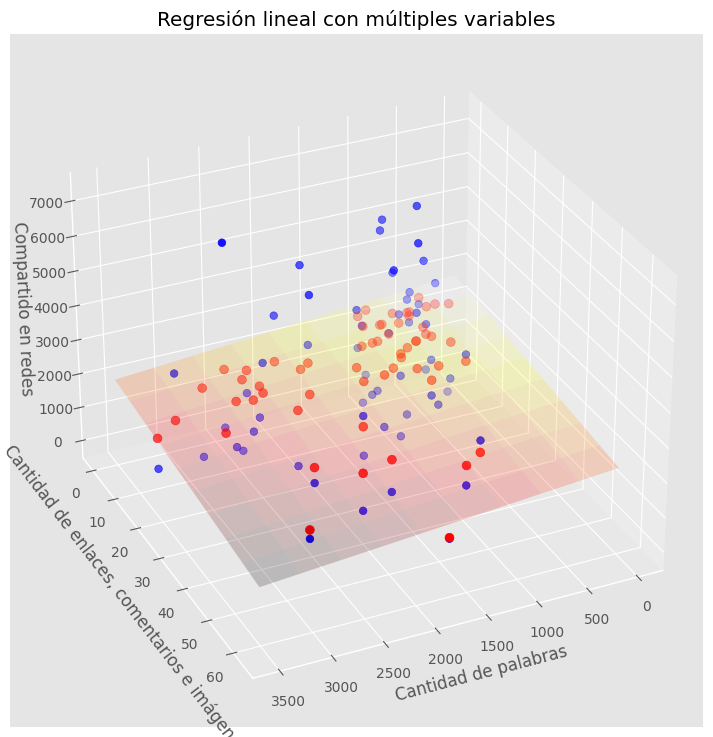

In [12]:
fig = plt.figure()
# En matplotlib >= 3.5, Axes3D(fig) ya no añade el eje a la figura
# automáticamente, lo que produce una figura vacía. La forma
# recomendada actualmente es usar add_subplot con projection='3d'.
ax = fig.add_subplot(111, projection='3d')

# Creamos una malla, sobre la cual graficaremos el plano.
xx, yy = np.meshgrid(np.linspace(0, 3500, num=10), np.linspace(0, 60, num=10))

# Calculamos los valores del plano para los puntos 'x' y 'y'.
nuevoX = (regr2.coef_[0] * xx)
nuevoY = (regr2.coef_[1] * yy)

# Calculamos los correspondientes valores para z. Sumamos el punto de intercepción.
z = (nuevoX + nuevoY + regr2.intercept_)

# Graficamos el plano
ax.plot_surface(xx, yy, z, alpha=0.2, cmap='hot')

# Graficamos en azul los puntos en 3D
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_train, c='blue', s=30)

# Graficamos en rojo los puntos predichos sobre el plano
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_pred, c='red', s=40)

# Con esto situamos la "cámara" con la que visualizamos.
ax.view_init(elev=30., azim=65)

ax.set_xlabel('Cantidad de palabras')
ax.set_ylabel('Cantidad de enlaces, comentarios e imágenes')
ax.set_zlabel('Compartido en redes')
ax.set_title('Regresión lineal con múltiples variables')

# Mostramos la figura: sin esto en algunos entornos la salida queda vacía.
plt.show()